# Semantic Book Intelligence Research Lab
## Notebook 06 — Scaled Genre Classification Stability and Calibration

**Primary research question**

> Do the classical and fixed-transformer genre-classification conclusions from Notebooks 04–05 remain stable on a larger, entirely fresh cohort when hyperparameters and per-label thresholds are evaluated with nested work-group cross-validation?

**Primary classification metric:** nested outer-fold Macro F1. Every included genre receives equal weight despite label imbalance.

**Secondary evidence:** Micro F1, macro average precision, Hamming loss, fold variability, learning curves, per-genre results, language slices, final fresh-holdout performance, runtime, and storage.

This notebook excludes every book and work used by the original 5,000-book sample, creates a new group-aware holdout, and never reuses the closed Notebook 04–05 test partition. Transformer fine-tuning, semantic-neighbor evaluation, human ratings, search, clustering, topic modeling, vector databases, and production services remain out of scope.


## Execution contract and expected resources

The first run streams the local 1.9 GB Goodreads books archive once, builds a deterministic sample of 25,000 description-eligible books, scans the genre archive, and generates two transformer embedding caches. Later runs reuse fingerprint-validated Parquet artifacts.

The nested classical text pipeline is intentionally the most expensive stage. Keep the **Python (Semantic Books)** kernel selected and run cells sequentially. The Notebook 04–05 test data is used only as an exclusion list and historical reference; no prior test labels or predictions participate in this experiment.

Notebook 06 is complete for Phase 1 only after the classification exports, measured interpretations, and final research checkpoint have been reviewed. The fresh test is accessed by exactly one pipeline selected under the predeclared nested-CV rule and is then permanently closed.


## 1. Imports, configuration, and reproducibility

In [6]:
from __future__ import annotations

from html import unescape
from pathlib import Path
from time import perf_counter
import gc
import gzip
import hashlib
import json
import re
import sys

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

import huggingface_hub
# Keep sentence-transformers ahead of direct sklearn/torch imports for macOS Conda OpenMP stability.
import sentence_transformers
import sklearn
import torch
import transformers
from sentence_transformers import SentenceTransformer
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    make_scorer,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit, cross_val_predict
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Freeze sampling, evaluation, calibration, and human-review decisions before results are visible.
RANDOM_STATE = 20260817
SCALED_SAMPLE_SIZE = 25_000
MIN_DESCRIPTION_WORDS = 20
FRESH_TEST_SIZE = 0.15
OUTER_CV_SPLITS = 4
INNER_CV_SPLITS = 3
FINAL_CV_SPLITS = 5
N_JOBS = -1
ENCODING_BATCH_SIZE = 32
MATERIAL_MACRO_F1_GAIN = 0.01
MIN_CALIBRATION_GAIN = 0.005
LEARNING_CURVE_REPEATS = 2
LEARNING_CURVE_TARGETS = [2_500, 5_000, 10_000]
CACHE_SCHEMA_VERSION = 2

# Preserve Notebook 04–05 label order so every metric and artifact remains comparable.
TARGET_GENRES = [
    "fiction",
    "history, historical fiction, biography",
    "romance",
    "non-fiction",
    "fantasy, paranormal",
    "mystery, thriller, crime",
    "young-adult",
    "children",
    "comics, graphic",
    "poetry",
]

# Resolve paths from the repository root or notebooks folder and use stable versioned artifacts.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "goodreads"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures" / "notebook06"
MODELS_DIR = PROJECT_ROOT / "models" / "notebook06"

for directory in [INTERIM_DIR, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FILES = {
    "raw_books": RAW_DIR / "goodreads_books.json.gz",
    "raw_genres": RAW_DIR / "goodreads_book_genres_initial.json.gz",
    "old_books": INTERIM_DIR / "books_sample.parquet",
    "old_split": PROCESSED_DIR / "research_split_v1.parquet",
    "scaled_books": INTERIM_DIR / "books_scaled_fresh_v2.parquet",
    "scaled_genres": INTERIM_DIR / "book_genres_scaled_fresh_v2.parquet",
    "scaled_manifest": MODELS_DIR / "scaled_cohort_manifest_v2.json",
    "fresh_split": PROCESSED_DIR / "research_split_v2.parquet",
    "historical_classical_test": REPORTS_DIR / "notebook04_final_test_metrics.csv",
    "historical_transformer_test": REPORTS_DIR / "notebook05_final_test_metrics.csv",
}

# Prefer available accelerators for embedding generation while keeping CPU as a reproducible fallback.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 24)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")

# Record exact package versions because tokenization and estimator behavior can change over time.
version_summary = pd.DataFrame(
    {
        "library": [
            "Python", "NumPy", "pandas", "scikit-learn", "PyTorch",
            "Transformers", "Sentence Transformers", "Hugging Face Hub",
            "Matplotlib", "seaborn",
        ],
        "version": [
            sys.version.split()[0], np.__version__, pd.__version__, sklearn.__version__,
            torch.__version__, transformers.__version__, sentence_transformers.__version__,
            huggingface_hub.__version__, matplotlib.__version__, sns.__version__,
        ],
    }
)
display(version_summary)
print(f"Embedding device: {DEVICE}; scaled target: {SCALED_SAMPLE_SIZE:,} described books")

,library,version
0,Python,3.12.13
1,NumPy,2.5.1
2,pandas,3.0.3
3,scikit-learn,1.9.0
4,PyTorch,2.13.0
5,Transformers,5.15.0
6,Sentence Transformers,5.7.0
7,Hugging Face Hub,1.27.0
8,Matplotlib,3.11.1
9,seaborn,0.13.2


Embedding device: mps; scaled target: 25,000 described books


## 2. Build or load a fresh scaled cohort

In [7]:
# Validate raw sources and prior exclusion artifacts before beginning the expensive stream.
required_inputs = [
    FILES["raw_books"], FILES["raw_genres"], FILES["old_books"], FILES["old_split"],
    FILES["historical_classical_test"], FILES["historical_transformer_test"],
]
file_status = pd.DataFrame(
    {
        "path": [str(path) for path in required_inputs],
        "exists": [path.exists() for path in required_inputs],
        "size_mb": [
            round(path.stat().st_size / (1024**2), 3) if path.exists() else np.nan
            for path in required_inputs
        ],
    }
)
display(file_status)
if not file_status["exists"].all():
    missing = file_status.loc[~file_status["exists"], "path"].tolist()
    raise FileNotFoundError("Notebook 06 inputs are missing:\n" + "\n".join(missing))

# Exclude the full original 5,000-book sample and every associated work from the new cohort.
old_books = pd.read_parquet(FILES["old_books"])
old_split = pd.read_parquet(FILES["old_split"])
old_book_ids = set(old_books["book_id"].astype("string"))

# Normalize identifiers before set comparisons so mixed source dtypes cannot defeat exclusions.
def normalize_identifier(value: object) -> str:
    if value is None or pd.isna(value):
        return ""
    return str(value).strip()


# Give missing work IDs book-specific groups; unrelated missing values must not collapse together.
def make_work_group(book_id: str, work_id: object) -> str:
    normalized_work_id = normalize_identifier(work_id)
    return normalized_work_id or f"__MISSING_WORK_{book_id}"


old_work_groups = {
    make_work_group(str(row.book_id), row.work_id)
    for row in old_books[["book_id", "work_id"]].itertuples(index=False)
}
old_work_groups.update(old_split["work_group"].astype("string"))

# Prior test scores provide orientation only and never participate in fresh model selection.
historical_benchmarks = pd.DataFrame(
    {
        "benchmark": ["Notebook 04 classical test", "Notebook 05 selected transformer test"],
        "macro_f1": [
            pd.read_csv(FILES["historical_classical_test"])["macro_f1"].iloc[0],
            pd.read_csv(FILES["historical_transformer_test"])["macro_f1"].iloc[0],
        ],
        "role": ["Historical context only", "Historical context only"],
    }
)
display(historical_benchmarks.round(4))
print(f"Excluded prior books: {len(old_book_ids):,}; excluded prior work groups: {len(old_work_groups):,}")

,path,exists,size_mb
0,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/g...,True,1986.692
1,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/g...,True,23.116
2,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/books_s...,True,3.292
3,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/resea...,True,0.095
4,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_f...,True,0.000
5,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_f...,True,0.000


,benchmark,macro_f1,role
0,Notebook 04 classical test,0.5681,Historical context only
1,Notebook 05 selected transformer test,0.5553,Historical context only


Excluded prior books: 5,000; excluded prior work groups: 4,982


In [8]:
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")


# Remove markup and URLs conservatively while retaining the book's natural-language content.
def normalize_description(value: object) -> str:
    if value is None or pd.isna(value):
        return ""
    text = unescape(str(value))
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()


def iter_gzip_json(path: Path):
    with gzip.open(path, "rt", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                yield json.loads(stripped)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path.name}, line {line_number}") from exc


def reservoir_sample_described_books(
    path: Path,
    sample_size: int,
    excluded_book_ids: set[str],
    excluded_work_groups: set[str],
    random_state: int,
) -> tuple[pd.DataFrame, dict[str, int]]:
    # Reservoir sampling stays uniform over all description-eligible records that pass exclusions.
    rng = np.random.default_rng(random_state)
    sample: list[dict[str, object]] = []
    raw_records_seen = 0
    eligible_records_seen = 0

    for record in iter_gzip_json(path):
        raw_records_seen += 1
        book_id = normalize_identifier(record.get("book_id"))
        if not book_id:
            continue
        work_group = make_work_group(book_id, record.get("work_id"))
        if book_id in excluded_book_ids or work_group in excluded_work_groups:
            continue

        clean_description = normalize_description(record.get("description"))
        text_word_count = len(clean_description.split())
        if text_word_count < MIN_DESCRIPTION_WORDS:
            continue

        candidate = {
            "book_id": book_id,
            "work_id": normalize_identifier(record.get("work_id")),
            "work_group": work_group,
            "title": str(record.get("title") or "Untitled").strip(),
            "language_code": normalize_identifier(record.get("language_code")),
            "clean_description": clean_description,
            "text_word_count": text_word_count,
        }

        if eligible_records_seen < sample_size:
            sample.append(candidate)
        else:
            replacement_position = int(rng.integers(0, eligible_records_seen + 1))
            if replacement_position < sample_size:
                sample[replacement_position] = candidate
        eligible_records_seen += 1

    if len(sample) != sample_size:
        raise ValueError(f"Requested {sample_size:,} books but sampled only {len(sample):,}.")

    return pd.DataFrame(sample), {
        "raw_records_seen": raw_records_seen,
        "eligible_records_seen": eligible_records_seen,
    }


def scan_target_genres(path: Path, sampled_book_ids: set[str]) -> pd.DataFrame:
    # Scan the compact genre archive once and retain only the predeclared target families.
    rows: list[dict[str, object]] = []
    for record in iter_gzip_json(path):
        book_id = normalize_identifier(record.get("book_id"))
        if book_id not in sampled_book_ids:
            continue
        genre_map = record.get("genres")
        if not isinstance(genre_map, dict):
            continue
        for genre, signal_count in genre_map.items():
            if genre in TARGET_GENRES:
                rows.append(
                    {
                        "book_id": book_id,
                        "genre": genre,
                        "genre_signal_count": pd.to_numeric(signal_count, errors="coerce"),
                    }
                )
    return pd.DataFrame(rows)


# Reuse a scaled cache only when the sampling contract matches the frozen experiment design.
expected_scaled_manifest = {
    "cache_schema_version": CACHE_SCHEMA_VERSION,
    "sample_size": SCALED_SAMPLE_SIZE,
    "random_state": RANDOM_STATE,
    "minimum_description_words": MIN_DESCRIPTION_WORDS,
    "excluded_original_sample": True,
}

cache_valid = False
if FILES["scaled_books"].exists() and FILES["scaled_genres"].exists() and FILES["scaled_manifest"].exists():
    with FILES["scaled_manifest"].open("r", encoding="utf-8") as handle:
        cached_manifest = json.load(handle)
    cache_valid = all(cached_manifest.get(key) == value for key, value in expected_scaled_manifest.items())

if cache_valid:
    scaled_books = pd.read_parquet(FILES["scaled_books"])
    scaled_genres = pd.read_parquet(FILES["scaled_genres"])
    sampling_diagnostics = cached_manifest["sampling_diagnostics"]
    scaled_cache_status = "loaded"
else:
    started_at = perf_counter()
    scaled_books, sampling_diagnostics = reservoir_sample_described_books(
        FILES["raw_books"], SCALED_SAMPLE_SIZE, old_book_ids, old_work_groups, RANDOM_STATE
    )
    scaled_genres = scan_target_genres(FILES["raw_genres"], set(scaled_books["book_id"]))
    scaled_books.to_parquet(FILES["scaled_books"], index=False)
    scaled_genres.to_parquet(FILES["scaled_genres"], index=False)
    cached_manifest = {
        **expected_scaled_manifest,
        "sampling_diagnostics": sampling_diagnostics,
        "generation_seconds": perf_counter() - started_at,
    }
    with FILES["scaled_manifest"].open("w", encoding="utf-8") as handle:
        json.dump(cached_manifest, handle, indent=2)
    scaled_cache_status = "generated"

for frame in [scaled_books, scaled_genres]:
    frame["book_id"] = frame["book_id"].astype("string")

if len(scaled_books) != SCALED_SAMPLE_SIZE or not scaled_books["book_id"].is_unique:
    raise ValueError("Scaled books cache must contain exactly 25,000 unique book IDs.")
if set(scaled_books["book_id"]) & old_book_ids:
    raise ValueError("Fresh scaled books overlap the original 5,000-book sample.")
if set(scaled_books["work_group"]) & old_work_groups:
    raise ValueError("Fresh scaled books overlap prior work groups.")

# Keep only sampled books with at least one target label and store labels in the frozen order.
genre_order = {genre: position for position, genre in enumerate(TARGET_GENRES)}
genre_lists = (
    scaled_genres.drop_duplicates(["book_id", "genre"])
    .groupby("book_id")["genre"]
    .agg(lambda values: tuple(sorted(set(values), key=genre_order.get)))
    .rename("genres")
)
analysis = scaled_books.merge(genre_lists, on="book_id", how="inner", validate="one_to_one")
analysis = analysis.sort_values("book_id").reset_index(drop=True)

if len(analysis) < 12_000:
    raise ValueError(f"Fresh labeled cohort is unexpectedly small: {len(analysis):,} books.")

label_binarizer = MultiLabelBinarizer(classes=TARGET_GENRES)
label_matrix = label_binarizer.fit_transform(analysis["genres"]).astype(np.int8)

# Collapse noisy language metadata into sufficiently large diagnostic slices, not verified languages.
ENGLISH_CODES = {"en", "eng", "en-us", "en-gb", "en-ca", "en-au"}
analysis["language_code_clean"] = (
    analysis["language_code"].fillna("").astype(str).str.strip().str.casefold().replace("", "unknown")
)
analysis["language_group"] = np.select(
    [analysis["language_code_clean"].isin(ENGLISH_CODES), analysis["language_code_clean"].eq("unknown")],
    ["English", "Unknown"],
    default="Non-English",
)

# Fingerprint row identity, grouping, text, and labels to prevent stale downstream cache reuse.
def cohort_fingerprint(frame: pd.DataFrame) -> str:
    hasher = hashlib.sha256()
    for row in frame[["book_id", "work_group", "clean_description", "genres"]].itertuples(index=False):
        hasher.update(str(row.book_id).encode("utf-8"))
        hasher.update(b"\0")
        hasher.update(str(row.work_group).encode("utf-8"))
        hasher.update(b"\0")
        hasher.update(row.clean_description.encode("utf-8"))
        hasher.update(b"\0")
        hasher.update("|".join(row.genres).encode("utf-8"))
        hasher.update(b"\n")
    return hasher.hexdigest()


COHORT_FINGERPRINT = cohort_fingerprint(analysis)
cached_manifest["eligible_labeled_books"] = len(analysis)
cached_manifest["eligible_work_groups"] = int(analysis["work_group"].nunique())
cached_manifest["cohort_fingerprint"] = COHORT_FINGERPRINT
with FILES["scaled_manifest"].open("w", encoding="utf-8") as handle:
    json.dump(cached_manifest, handle, indent=2)

print(
    f"Scaled cohort {scaled_cache_status}: {len(analysis):,} labeled books across "
    f"{analysis['work_group'].nunique():,} work groups."
)
display(pd.Series(sampling_diagnostics, name="value").rename_axis("sampling_diagnostic").to_frame())

Scaled cohort loaded: 21,699 labeled books across 20,921 work groups.


,value
sampling_diagnostic,
raw_records_seen,2360655
eligible_records_seen,1859208


,books,work_groups,median_words,share
language_group,,,,
English,9198,9066,139.0,0.4239
Non-English,3714,3538,115.0,0.1712
Unknown,8787,8702,129.0,0.4049


,genre,books,share
0,fiction,14279,0.6580
2,romance,7839,0.3613
1,"history, historical fiction, biography",7455,0.3436
4,"fantasy, paranormal",6287,0.2897
5,"mystery, thriller, crime",6017,0.2773
3,non-fiction,5876,0.2708
6,young-adult,4322,0.1992
7,children,2831,0.1305
8,"comics, graphic",1818,0.0838
9,poetry,863,0.0398


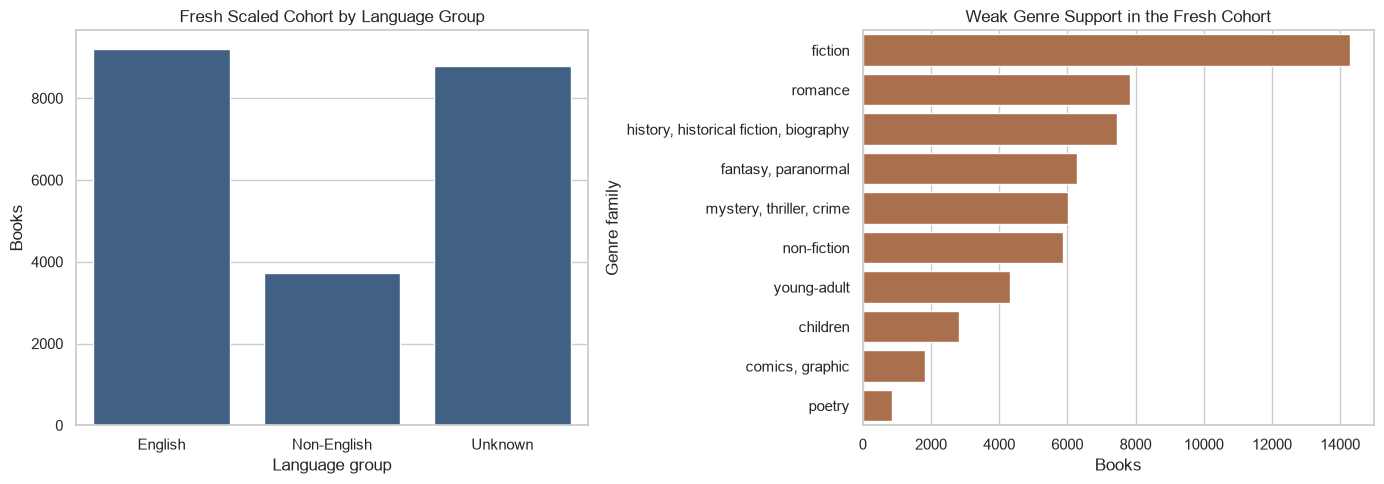


### Result interpretation — fresh cohort

- The new cohort contains **21,699** labeled books across **20,921** work groups and excludes every book/work from the original sample.
- Non-English metadata codes account for **17.1%** and unknown codes for **40.5%**. These groups are large enough for per-encoder diagnostics, although codes remain metadata rather than verified language detection.
- Genre labels remain weak Goodreads signals. Support and co-occurrence should be considered when interpreting Macro F1 and human-neighbor judgments.


In [9]:
# Profile label and language coverage before creating any evaluation partition.
label_prevalence = pd.DataFrame(
    {"genre": TARGET_GENRES, "books": label_matrix.sum(axis=0).astype(int)}
).sort_values("books", ascending=False)
label_prevalence["share"] = label_prevalence["books"] / len(analysis)

cohort_profile = (
    analysis.groupby("language_group", observed=True)
    .agg(books=("book_id", "size"), work_groups=("work_group", "nunique"), median_words=("text_word_count", "median"))
    .reindex(["English", "Non-English", "Unknown"])
)
cohort_profile["share"] = cohort_profile["books"] / len(analysis)
display(cohort_profile.round(4))
display(label_prevalence.round(4))

# Show language composition beside label imbalance because both can explain aggregate score differences.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=cohort_profile.reset_index(), x="language_group", y="books", color="#35618f", ax=axes[0])
axes[0].set_title("Fresh Scaled Cohort by Language Group")
axes[0].set_xlabel("Language group")
axes[0].set_ylabel("Books")

sns.barplot(data=label_prevalence, y="genre", x="books", color="#ba6b3d", ax=axes[1])
axes[1].set_title("Weak Genre Support in the Fresh Cohort")
axes[1].set_xlabel("Books")
axes[1].set_ylabel("Genre family")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fresh_cohort_profile.png", dpi=160, bbox_inches="tight")
plt.show()

# Generate a measured interpretation from the displayed cohort rather than relying on static prose.
display(
    Markdown(
        f'''
### Result interpretation — fresh cohort

- The new cohort contains **{len(analysis):,}** labeled books across **{analysis['work_group'].nunique():,}** work groups and excludes every book/work from the original sample.
- Non-English metadata codes account for **{cohort_profile.loc['Non-English', 'share']:.1%}** and unknown codes for **{cohort_profile.loc['Unknown', 'share']:.1%}**. These groups are large enough for per-encoder diagnostics, although codes remain metadata rather than verified language detection.
- Genre labels remain weak Goodreads signals. Support and co-occurrence should be considered when interpreting Macro F1 and human-neighbor judgments.
'''
    )
)

## 3. Create a fresh work-group holdout

In [10]:
def create_fresh_split_manifest(frame: pd.DataFrame) -> pd.DataFrame:
    # Reserve a new final test partition; nested CV operates only on the remaining development books.
    splitter = GroupShuffleSplit(n_splits=1, test_size=FRESH_TEST_SIZE, random_state=RANDOM_STATE + 1)
    development_positions, test_positions = next(splitter.split(frame, groups=frame["work_group"]))
    split = np.full(len(frame), "development", dtype=object)
    split[test_positions] = "test"
    return pd.DataFrame(
        {
            "book_id": frame["book_id"].to_numpy(),
            "work_id": frame["work_id"].to_numpy(),
            "work_group": frame["work_group"].to_numpy(),
            "split": split,
            "random_state": RANDOM_STATE + 1,
            "cohort_fingerprint": COHORT_FINGERPRINT,
        }
    )


# Reuse a split only after verifying its cohort fingerprint and restoring current row order.
if FILES["fresh_split"].exists():
    fresh_split = pd.read_parquet(FILES["fresh_split"])
    fresh_split["book_id"] = fresh_split["book_id"].astype("string")
    if fresh_split["cohort_fingerprint"].nunique() != 1 or fresh_split["cohort_fingerprint"].iloc[0] != COHORT_FINGERPRINT:
        raise ValueError("research_split_v2.parquet belongs to a different scaled cohort.")
    aligned_split = fresh_split.set_index("book_id").reindex(analysis["book_id"])
    if aligned_split["split"].isna().any():
        raise ValueError("research_split_v2.parquet is missing fresh cohort book IDs.")
    fresh_split = aligned_split.reset_index()
else:
    fresh_split = create_fresh_split_manifest(analysis)
    fresh_split.to_parquet(FILES["fresh_split"], index=False)

# Convert the aligned split into masks once so every later representation uses identical rows.
analysis["split"] = fresh_split["split"].to_numpy()
development_mask = analysis["split"].eq("development").to_numpy()
test_mask = analysis["split"].eq("test").to_numpy()

# Verify group disjointness and label availability before any representation is fitted.
development_groups_set = set(analysis.loc[development_mask, "work_group"])
test_groups_set = set(analysis.loc[test_mask, "work_group"])
if development_groups_set & test_groups_set:
    raise RuntimeError("Work-group leakage exists between development and fresh test partitions.")

# Require every genre in both partitions; absent test labels would make Macro F1 misleading.
coverage = pd.DataFrame(label_matrix, columns=TARGET_GENRES)
coverage["split"] = analysis["split"].to_numpy()
coverage = coverage.groupby("split")[TARGET_GENRES].sum().T.astype(int)
if (coverage[["development", "test"]] == 0).any().any():
    raise ValueError("Every target genre must appear in development and fresh test.")

split_summary = (
    analysis.groupby("split", observed=True)
    .agg(books=("book_id", "size"), work_groups=("work_group", "nunique"))
    .reindex(["development", "test"])
)
split_summary["share"] = split_summary["books"] / len(analysis)
display(split_summary.round(4))
display(coverage)
print("Prior-sample book overlap:", len(set(analysis["book_id"]) & old_book_ids))
print("Prior-sample work overlap:", len(set(analysis["work_group"]) & old_work_groups))

,books,work_groups,share
split,,,
development,18462,17782,0.8508
test,3237,3139,0.1492


split,development,test
fiction,12150,2129
"history, historical fiction, biography",6294,1161
romance,6661,1178
non-fiction,4972,904
"fantasy, paranormal",5372,915
"mystery, thriller, crime",5105,912
young-adult,3694,628
children,2432,399
"comics, graphic",1531,287
poetry,729,134


Prior-sample book overlap: 0
Prior-sample work overlap: 0


## 4. Generate or load scaled transformer embeddings

In [12]:
# Pin model revisions and required prefixes so reruns encode the same text with the same weights.
MODEL_CONFIGS = [
    {
        "embedding_name": "MiniLM English",
        "slug": "minilm_english",
        "model_id": "sentence-transformers/all-MiniLM-L6-v2",
        "revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41",
        "text_prefix": "",
        "expected_dimension": 384,
    },
    {
        "embedding_name": "Multilingual E5 Small",
        "slug": "multilingual_e5_small",
        "model_id": "intfloat/multilingual-e5-small",
        "revision": "fd1525a9fd15316a2d503bf26ab031a61d056e98",
        "text_prefix": "query: ",
        "expected_dimension": 384,
    },
]


# Unit-normalize pooled book vectors so cosine comparisons are consistent across encoders.
def normalize_embedding_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    if (norms == 0).any():
        raise ValueError("Embedding generation produced at least one zero vector.")
    return (matrix / norms).astype(np.float32)


def prepare_token_chunks(texts: list[str], tokenizer: object, max_length: int, prefix: str):
    # Token-aware chunks avoid silent truncation while preserving deterministic book ownership.
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    special_tokens = tokenizer.num_special_tokens_to_add(pair=False)
    available = max_length - len(prefix_ids) - special_tokens
    if available < 32:
        raise ValueError("Encoder context leaves too little room for description text.")

    chunks: list[str] = []
    owners: list[int] = []
    token_counts: list[int] = []
    for owner, text in enumerate(texts):
        body_ids = tokenizer.encode(text, add_special_tokens=False)
        token_counts.append(len(prefix_ids) + len(body_ids) + special_tokens)
        for start in range(0, max(len(body_ids), 1), available):
            body = tokenizer.decode(
                body_ids[start : start + available],
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )
            chunks.append(f"{prefix}{body}".strip())
            owners.append(owner)
    return chunks, np.asarray(owners, dtype=np.int64), np.asarray(token_counts, dtype=np.int32)


def load_or_create_scaled_embeddings(config: dict[str, object]):
    cache_path = PROCESSED_DIR / f"book_transformer_embeddings_{config['slug']}_v2.parquet"
    manifest_path = MODELS_DIR / f"{config['slug']}_embedding_manifest_v2.json"

    # Validate model, revision, cohort, and row order before trusting an embedding cache.
    if cache_path.exists() and manifest_path.exists():
        with manifest_path.open("r", encoding="utf-8") as handle:
            manifest = json.load(handle)
        valid = all(
            [
                manifest.get("cache_schema_version") == CACHE_SCHEMA_VERSION,
                manifest.get("model_id") == config["model_id"],
                manifest.get("revision") == config["revision"],
                manifest.get("cohort_fingerprint") == COHORT_FINGERPRINT,
                manifest.get("rows") == len(analysis),
            ]
        )
        if valid:
            cached = pd.read_parquet(cache_path)
            if not cached["book_id"].astype("string").equals(analysis["book_id"]):
                raise ValueError(f"Cached embedding order mismatch: {cache_path}")
            columns = [column for column in cached if column.startswith("embedding_")]
            matrix = cached[columns].to_numpy(dtype=np.float32)
            return matrix, {**manifest, "cache_status": "loaded", "cache_size_mb": cache_path.stat().st_size / (1024**2)}

    started_at = perf_counter()
    model = SentenceTransformer(
        config["model_id"], revision=config["revision"], device=DEVICE, trust_remote_code=False
    )
    max_length = int(model.max_seq_length)
    chunks, owners, token_counts = prepare_token_chunks(
        analysis["clean_description"].tolist(), model.tokenizer, max_length, str(config["text_prefix"])
    )
    chunk_embeddings = model.encode(
        chunks,
        batch_size=ENCODING_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)

    # Average all chunks belonging to each book, then renormalize the pooled book vector.
    matrix = np.zeros((len(analysis), chunk_embeddings.shape[1]), dtype=np.float32)
    np.add.at(matrix, owners, chunk_embeddings)
    matrix /= np.bincount(owners, minlength=len(analysis)).astype(np.float32)[:, None]
    matrix = normalize_embedding_rows(matrix)
    if matrix.shape[1] != config["expected_dimension"]:
        raise ValueError(f"Unexpected embedding width for {config['embedding_name']}: {matrix.shape[1]}")

    columns = [f"embedding_{position:03d}" for position in range(matrix.shape[1])]
    cached = pd.DataFrame(matrix, columns=columns)
    cached.insert(0, "split", analysis["split"].to_numpy())
    cached.insert(0, "work_id", analysis["work_id"].to_numpy())
    cached.insert(0, "book_id", analysis["book_id"].to_numpy())
    cached.to_parquet(cache_path, index=False)

    # Persist provenance and truncation diagnostics alongside the numerical embedding cache.
    manifest = {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "embedding_name": config["embedding_name"],
        "model_id": config["model_id"],
        "revision": config["revision"],
        "text_prefix": config["text_prefix"],
        "cohort_fingerprint": COHORT_FINGERPRINT,
        "rows": len(analysis),
        "embedding_dimension": matrix.shape[1],
        "max_sequence_length": max_length,
        "multi_chunk_rate": float((token_counts > max_length).mean()),
        "total_chunks": len(chunks),
        "maximum_raw_tokens": int(token_counts.max()),
        "generation_seconds": perf_counter() - started_at,
        "device": DEVICE,
        "batch_size": ENCODING_BATCH_SIZE,
    }
    with manifest_path.open("w", encoding="utf-8") as handle:
        json.dump(manifest, handle, indent=2)

    # Release encoder memory before loading the next model in the same notebook kernel.
    del model, chunk_embeddings
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE == "mps" and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()

    return matrix, {**manifest, "cache_status": "generated", "cache_size_mb": cache_path.stat().st_size / (1024**2)}

In [13]:
# Create both representations in the identical fresh cohort order and summarize reusable artifacts.
embedding_matrices: dict[str, np.ndarray] = {}
embedding_manifests: list[dict[str, object]] = []
for config in MODEL_CONFIGS:
    matrix, manifest = load_or_create_scaled_embeddings(config)
    embedding_matrices[config["embedding_name"]] = matrix
    embedding_manifests.append(manifest)
    print(
        f"{config['embedding_name']}: {manifest['cache_status']}; "
        f"{matrix.shape[0]:,} x {matrix.shape[1]}; {manifest['multi_chunk_rate']:.1%} multi-chunk"
    )

# Keep the compact inventory visible; full vectors remain in Parquet rather than notebook output.
embedding_inventory = pd.DataFrame(embedding_manifests)[
    [
        "embedding_name", "model_id", "revision", "rows", "embedding_dimension",
        "max_sequence_length", "multi_chunk_rate", "total_chunks", "maximum_raw_tokens",
        "generation_seconds", "cache_status", "cache_size_mb", "device",
    ]
]
display(embedding_inventory.round(4))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (261 > 256). Running this sequence through the model will result in indexing errors


MiniLM English: generated; 21,699 x 384; 27.6% multi-chunk


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (522 > 512). Running this sequence through the model will result in indexing errors


Multilingual E5 Small: generated; 21,699 x 384; 3.4% multi-chunk


,embedding_name,model_id,revision,rows,embedding_dimension,max_sequence_length,multi_chunk_rate,total_chunks,maximum_raw_tokens,generation_seconds,cache_status,cache_size_mb,device
0,MiniLM English,sentence-transformers/all-MiniLM-L6-v2,1110a243fdf4706b3f48f1d95db1a4f5529b4d41,21699,384,256,0.2761,28686,3066,47.9203,generated,47.1103,mps
1,Multilingual E5 Small,intfloat/multilingual-e5-small,fd1525a9fd15316a2d503bf26ab031a61d056e98,21699,384,512,0.0339,22499,3259,87.6411,generated,47.1042,mps


## 5. Candidate pipelines, metrics, and calibration utilities

In [15]:
# Word n-grams capture lexical topics; character n-grams add robustness to morphology and spelling.
def word_vectorizer() -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer="word", lowercase=True, strip_accents="unicode", ngram_range=(1, 2),
        min_df=3, max_df=0.95, max_features=40_000, sublinear_tf=True, dtype=np.float32,
    )


def character_vectorizer() -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer="char_wb", lowercase=True, ngram_range=(3, 5), min_df=3,
        max_features=30_000, sublinear_tf=True, dtype=np.float32,
    )


# Keep model families and bounded regularization grids explicit before nested evaluation begins.
CANDIDATE_CONFIGS = {
    "Classical Word + Character TF-IDF": {
        "kind": "classical",
        "classifier": "Linear SVM",
        "c_grid": [0.02, 0.05, 0.1],
        "frozen_curve_c": 0.05,
    },
    "MiniLM English": {
        "kind": "dense",
        "classifier": "Logistic Regression",
        "c_grid": [0.03, 0.1, 0.3],
        "frozen_curve_c": 0.1,
    },
    "Multilingual E5 Small": {
        "kind": "dense",
        "classifier": "Logistic Regression",
        "c_grid": [0.03, 0.1, 0.3],
        "frozen_curve_c": 0.1,
    },
}


def build_candidate_pipeline(candidate_name: str) -> Pipeline:
    # Each fresh builder keeps fitted vocabulary, scaling, and classifier state inside CV folds.
    config = CANDIDATE_CONFIGS[candidate_name]
    if config["kind"] == "classical":
        return Pipeline(
            [
                ("features", FeatureUnion([("word", word_vectorizer()), ("character", character_vectorizer())])),
                (
                    "classifier",
                    OneVsRestClassifier(
                        LinearSVC(
                            dual="auto", tol=1e-3, max_iter=10_000,
                            class_weight="balanced", random_state=RANDOM_STATE,
                        )
                    ),
                ),
            ]
        )
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                OneVsRestClassifier(
                    LogisticRegression(
                        solver="liblinear", max_iter=5_000,
                        class_weight="balanced", random_state=RANDOM_STATE,
                    )
                ),
            ),
        ]
    )


def parameter_grid(candidate_name: str) -> dict[str, list[float]]:
    return {"classifier__estimator__C": CANDIDATE_CONFIGS[candidate_name]["c_grid"]}


# Express both estimator families on a zero-centered decision scale for shared threshold logic.
def continuous_scores(estimator: Pipeline, features: np.ndarray) -> np.ndarray:
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(features))
    probabilities = np.asarray(estimator.predict_proba(features))
    return probabilities - 0.5


def tune_per_label_thresholds(true_labels: np.ndarray, scores: np.ndarray) -> np.ndarray:
    # Thresholds are selected only on inner out-of-fold scores; outer folds remain untouched.
    thresholds = np.zeros(scores.shape[1], dtype=np.float32)
    # Search score quantiles rather than an arbitrary absolute grid, which adapts to each label.
    quantiles = np.linspace(0.01, 0.99, 81)
    for label_position in range(scores.shape[1]):
        label_scores = scores[:, label_position]
        candidates = np.unique(np.concatenate([np.quantile(label_scores, quantiles), [0.0]]))
        evaluated = [
            (
                f1_score(true_labels[:, label_position], label_scores >= threshold, zero_division=0),
                -abs(float(threshold)),
                float(threshold),
            )
            for threshold in candidates
        ]
        thresholds[label_position] = max(evaluated)[2]
    return thresholds


def predictions_from_thresholds(scores: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    return (scores >= thresholds.reshape(1, -1)).astype(np.int8)


# Macro F1 is primary; supporting metrics expose prevalence, ranking, and exact-match tradeoffs.
def multilabel_metrics(true_labels: np.ndarray, predictions: np.ndarray, scores: np.ndarray | None = None):
    values = {
        "macro_f1": f1_score(true_labels, predictions, average="macro", zero_division=0),
        "micro_f1": f1_score(true_labels, predictions, average="micro", zero_division=0),
        "weighted_f1": f1_score(true_labels, predictions, average="weighted", zero_division=0),
        "subset_accuracy": accuracy_score(true_labels, predictions),
        "hamming_loss": hamming_loss(true_labels, predictions),
    }
    values["macro_average_precision"] = (
        average_precision_score(true_labels, scores, average="macro") if scores is not None else np.nan
    )
    return values


macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)
micro_scorer = make_scorer(f1_score, average="micro", zero_division=0)
SCORING = {"macro_f1": macro_scorer, "micro_f1": micro_scorer}

# Candidate features remain aligned to analysis rows; only training folds fit learned transforms.
candidate_features = {
    "Classical Word + Character TF-IDF": analysis["clean_description"].to_numpy(dtype=object),
    "MiniLM English": embedding_matrices["MiniLM English"],
    "Multilingual E5 Small": embedding_matrices["Multilingual E5 Small"],
}

# Materialize shared development/test positions once to preserve row alignment across modalities.
development_positions = np.flatnonzero(development_mask)
test_positions = np.flatnonzero(test_mask)
y_development = label_matrix[development_mask]
y_test = label_matrix[test_mask]
development_groups = analysis.loc[development_mask, "work_group"].to_numpy()

candidate_design = pd.DataFrame(
    [
        {
            "candidate": name,
            "representation_kind": config["kind"],
            "classifier": config["classifier"],
            "c_grid": config["c_grid"],
            "threshold_policies": "Default and inner-OOF tuned",
        }
        for name, config in CANDIDATE_CONFIGS.items()
    ]
)
display(candidate_design)

,candidate,representation_kind,classifier,c_grid,threshold_policies
0,Classical Word + Character TF-IDF,classical,Linear SVM,"[0.02, 0.05, 0.1]",Default and inner-OOF tuned
1,MiniLM English,dense,Logistic Regression,"[0.03, 0.1, 0.3]",Default and inner-OOF tuned
2,Multilingual E5 Small,dense,Logistic Regression,"[0.03, 0.1, 0.3]",Default and inner-OOF tuned


## 6. Nested work-group cross-validation

Each outer fold is a genuinely unseen evaluation fold. Within each outer-training partition, an inner grouped grid search selects regularization, and a second inner out-of-fold pass learns per-label thresholds. Both default and calibrated predictions are then evaluated on the untouched outer fold.

Candidate selection uses nested mean Macro F1. A tuned policy must improve its own default policy by at least 0.005; a transformer must improve the classical candidate by at least 0.01 to become the final fresh-test candidate. These rules are fixed before the fresh test is accessed.

In [16]:
# Outer folds estimate generalization; no outer-validation row informs tuning or calibration.
def nested_group_evaluation(candidate_name: str, features: np.ndarray):
    outer_cv = GroupKFold(n_splits=OUTER_CV_SPLITS)
    fold_rows: list[dict[str, object]] = []
    oof_scores = np.zeros_like(y_development, dtype=np.float32)
    oof_default = np.zeros_like(y_development, dtype=np.int8)
    oof_tuned = np.zeros_like(y_development, dtype=np.int8)
    oof_fold = np.full(len(y_development), -1, dtype=np.int8)

    for outer_fold, (outer_train, outer_valid) in enumerate(
        outer_cv.split(features, y_development, groups=development_groups), start=1
    ):
        started_at = perf_counter()
        inner_cv = GroupKFold(n_splits=INNER_CV_SPLITS)
        # Select regularization entirely inside the current outer-training partition.
        search = GridSearchCV(
            build_candidate_pipeline(candidate_name),
            parameter_grid(candidate_name),
            scoring=SCORING,
            refit="macro_f1",
            cv=inner_cv,
            n_jobs=N_JOBS,
            error_score="raise",
            return_train_score=False,
        )
        search.fit(
            features[outer_train], y_development[outer_train],
            groups=development_groups[outer_train],
        )

        # Generate honest inner OOF scores so threshold tuning never sees fitted-row scores.
        inner_scores = cross_val_predict(
            clone(search.best_estimator_),
            features[outer_train],
            y_development[outer_train],
            groups=development_groups[outer_train],
            cv=GroupKFold(n_splits=INNER_CV_SPLITS),
            method="decision_function",
            n_jobs=N_JOBS,
        )
        thresholds = tune_per_label_thresholds(y_development[outer_train], inner_scores)

        valid_scores = continuous_scores(search.best_estimator_, features[outer_valid])
        default_predictions = np.asarray(search.best_estimator_.predict(features[outer_valid])).astype(np.int8)
        tuned_predictions = predictions_from_thresholds(valid_scores, thresholds)

        # Store one untouched prediction per development row for later slice diagnostics.
        oof_scores[outer_valid] = valid_scores
        oof_default[outer_valid] = default_predictions
        oof_tuned[outer_valid] = tuned_predictions
        oof_fold[outer_valid] = outer_fold

        # Evaluate both threshold policies on the same scores and outer-validation books.
        for policy, predictions in [("Default", default_predictions), ("Inner-OOF tuned", tuned_predictions)]:
            fold_rows.append(
                {
                    "candidate": candidate_name,
                    "threshold_policy": policy,
                    "outer_fold": outer_fold,
                    "outer_validation_books": len(outer_valid),
                    "inner_best_macro_f1": search.best_score_,
                    "best_parameters": json.dumps(search.best_params_, sort_keys=True),
                    "fit_and_calibration_seconds": perf_counter() - started_at,
                    **multilabel_metrics(y_development[outer_valid], predictions, valid_scores),
                }
            )

        print(
            f"{candidate_name} | outer fold {outer_fold}: "
            f"default={fold_rows[-2]['macro_f1']:.3f}; tuned={fold_rows[-1]['macro_f1']:.3f}"
        )

    if (oof_fold < 0).any():
        raise RuntimeError(f"Nested OOF predictions are incomplete for {candidate_name}.")

    return pd.DataFrame(fold_rows), {
        "scores": oof_scores,
        "Default": oof_default,
        "Inner-OOF tuned": oof_tuned,
        "outer_fold": oof_fold,
    }

Classical Word + Character TF-IDF | outer fold 1: default=0.644; tuned=0.644
Classical Word + Character TF-IDF | outer fold 2: default=0.645; tuned=0.646
Classical Word + Character TF-IDF | outer fold 3: default=0.647; tuned=0.650
Classical Word + Character TF-IDF | outer fold 4: default=0.650; tuned=0.654
MiniLM English | outer fold 1: default=0.578; tuned=0.613
MiniLM English | outer fold 2: default=0.577; tuned=0.619
MiniLM English | outer fold 3: default=0.578; tuned=0.614
MiniLM English | outer fold 4: default=0.582; tuned=0.624
Multilingual E5 Small | outer fold 1: default=0.612; tuned=0.649
Multilingual E5 Small | outer fold 2: default=0.614; tuned=0.650
Multilingual E5 Small | outer fold 3: default=0.613; tuned=0.652
Multilingual E5 Small | outer fold 4: default=0.615; tuned=0.666


,candidate,threshold_policy,nested_macro_f1_mean,nested_macro_f1_std,nested_micro_f1_mean,nested_macro_ap_mean,nested_hamming_loss_mean,total_fit_seconds
0,Multilingual E5 Small,Inner-OOF tuned,0.6543,0.0078,0.7264,0.6923,0.1540,90.5344
1,Classical Word + Character TF-IDF,Inner-OOF tuned,0.6485,0.0041,0.7177,0.6978,0.1614,273.2023
2,Classical Word + Character TF-IDF,Default,0.6465,0.0026,0.7118,0.6978,0.1572,273.1379
3,MiniLM English,Inner-OOF tuned,0.6174,0.0050,0.6960,0.6549,0.1744,140.3889
4,Multilingual E5 Small,Default,0.6133,0.0013,0.6774,0.6923,0.1963,90.4701
5,MiniLM English,Default,0.5789,0.0019,0.6418,0.6549,0.2229,140.3243


,candidate,chosen_policy,calibration_gain,selection_macro_f1,selection_macro_f1_std
2,Multilingual E5 Small,Inner-OOF tuned,0.0410,0.6543,0.0078
0,Classical Word + Character TF-IDF,Default,0.0020,0.6465,0.0026
1,MiniLM English,Inner-OOF tuned,0.0386,0.6174,0.0050


Locked fresh-test candidate: Classical Word + Character TF-IDF / Default
Transformer did not exceed the material nested-CV gain criterion.


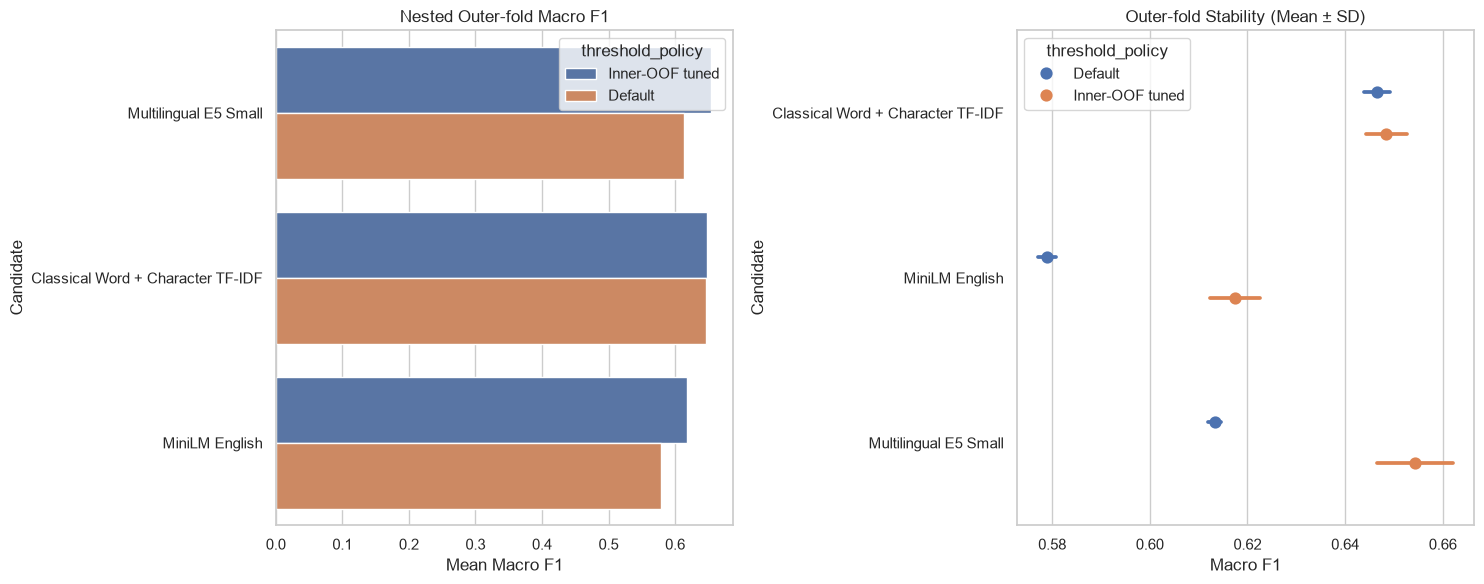


### Result interpretation — nested selection

- The strongest transformer after applying the calibration rule is **Multilingual E5 Small / Inner-OOF tuned** at nested Macro F1 **0.6543**.
- The comparable classical result is **0.6465**; the transformer change is **+0.0078** against the predeclared +0.01 material criterion.
- The locked fresh-test candidate is **Classical Word + Character TF-IDF / Default**. The fresh test has not been accessed at this point.


In [17]:
# Run the same nested protocol for the frozen classical pipeline and both transformer candidates.
nested_fold_frames: list[pd.DataFrame] = []
nested_oof: dict[str, dict[str, np.ndarray]] = {}

for candidate_name, full_features in candidate_features.items():
    development_features = full_features[development_mask]
    fold_frame, oof_artifacts = nested_group_evaluation(candidate_name, development_features)
    nested_fold_frames.append(fold_frame)
    nested_oof[candidate_name] = oof_artifacts

# Summarize both mean performance and fold variability before applying selection rules.
nested_fold_results = pd.concat(nested_fold_frames, ignore_index=True)
nested_summary = (
    nested_fold_results.groupby(["candidate", "threshold_policy"], as_index=False)
    .agg(
        nested_macro_f1_mean=("macro_f1", "mean"),
        nested_macro_f1_std=("macro_f1", "std"),
        nested_micro_f1_mean=("micro_f1", "mean"),
        nested_macro_ap_mean=("macro_average_precision", "mean"),
        nested_hamming_loss_mean=("hamming_loss", "mean"),
        total_fit_seconds=("fit_and_calibration_seconds", "sum"),
    )
    .sort_values(["nested_macro_f1_mean", "nested_macro_f1_std"], ascending=[False, True])
    .reset_index(drop=True)
)

# Enforce the predeclared minimum calibration gain separately for each representation.
candidate_selection_rows = []
for candidate_name in CANDIDATE_CONFIGS:
    candidate_rows = nested_summary.loc[nested_summary["candidate"] == candidate_name].set_index("threshold_policy")
    default_row = candidate_rows.loc["Default"]
    tuned_row = candidate_rows.loc["Inner-OOF tuned"]
    calibration_gain = tuned_row["nested_macro_f1_mean"] - default_row["nested_macro_f1_mean"]
    chosen_policy = "Inner-OOF tuned" if calibration_gain >= MIN_CALIBRATION_GAIN else "Default"
    chosen_row = candidate_rows.loc[chosen_policy]
    candidate_selection_rows.append(
        {
            "candidate": candidate_name,
            "chosen_policy": chosen_policy,
            "calibration_gain": calibration_gain,
            "selection_macro_f1": chosen_row["nested_macro_f1_mean"],
            "selection_macro_f1_std": chosen_row["nested_macro_f1_std"],
        }
    )

candidate_selection = pd.DataFrame(candidate_selection_rows).sort_values("selection_macro_f1", ascending=False)
classical_selection = candidate_selection.loc[
    candidate_selection["candidate"] == "Classical Word + Character TF-IDF"
].iloc[0]
best_transformer_selection = candidate_selection.loc[
    candidate_selection["candidate"] != "Classical Word + Character TF-IDF"
].iloc[0]
transformer_gain = best_transformer_selection["selection_macro_f1"] - classical_selection["selection_macro_f1"]

# Lock a transformer only when its nested gain clears the predeclared material threshold.
if transformer_gain >= MATERIAL_MACRO_F1_GAIN:
    selected_candidate = str(best_transformer_selection["candidate"])
    selected_policy = str(best_transformer_selection["chosen_policy"])
    selection_reason = "Transformer exceeded the material nested-CV gain criterion."
else:
    selected_candidate = str(classical_selection["candidate"])
    selected_policy = str(classical_selection["chosen_policy"])
    selection_reason = "Transformer did not exceed the material nested-CV gain criterion."

selected_nested_row = candidate_selection.loc[candidate_selection["candidate"] == selected_candidate].iloc[0]
display(nested_summary.round(4))
display(candidate_selection.round(4))
print(f"Locked fresh-test candidate: {selected_candidate} / {selected_policy}")
print(selection_reason)

# Pair ranking with fold spread so a small mean gain is not mistaken for stable improvement.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(
    data=nested_summary, y="candidate", x="nested_macro_f1_mean", hue="threshold_policy",
    orient="h", ax=axes[0],
)
axes[0].set_title("Nested Outer-fold Macro F1")
axes[0].set_xlabel("Mean Macro F1")
axes[0].set_ylabel("Candidate")

sns.pointplot(
    data=nested_fold_results, y="candidate", x="macro_f1", hue="threshold_policy",
    dodge=0.25, errorbar="sd", linestyles="none", ax=axes[1],
)
axes[1].set_title("Outer-fold Stability (Mean ± SD)")
axes[1].set_xlabel("Macro F1")
axes[1].set_ylabel("Candidate")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "nested_candidate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(
    Markdown(
        f'''
### Result interpretation — nested selection

- The strongest transformer after applying the calibration rule is **{best_transformer_selection['candidate']} / {best_transformer_selection['chosen_policy']}** at nested Macro F1 **{best_transformer_selection['selection_macro_f1']:.4f}**.
- The comparable classical result is **{classical_selection['selection_macro_f1']:.4f}**; the transformer change is **{transformer_gain:+.4f}** against the predeclared +{MATERIAL_MACRO_F1_GAIN:.2f} material criterion.
- The locked fresh-test candidate is **{selected_candidate} / {selected_policy}**. The fresh test has not been accessed at this point.
'''
    )
)

## 7. Group-aware learning curves with frozen default thresholds

,candidate,target_training_books,actual_training_books,macro_f1_mean,macro_f1_std,fit_seconds_mean
0,Classical Word + Character TF-IDF,2500,2500.0,0.5976,0.0148,5.7144
1,Classical Word + Character TF-IDF,5000,5000.0,0.6217,0.0056,9.1421
2,Classical Word + Character TF-IDF,10000,10000.0,0.6404,0.0017,16.2873
3,Classical Word + Character TF-IDF,14753,14753.0,0.6485,NaN,22.8314
4,Classical Word + Character TF-IDF,14763,14763.0,0.6435,NaN,22.5423
5,MiniLM English,2500,2500.0,0.5499,0.0036,1.3667
6,MiniLM English,5000,5000.0,0.5655,0.0041,3.4762
7,MiniLM English,10000,10000.0,0.5759,0.0044,8.1653
8,MiniLM English,14753,14753.0,0.5862,NaN,13.3377
9,MiniLM English,14763,14763.0,0.5788,NaN,13.4357


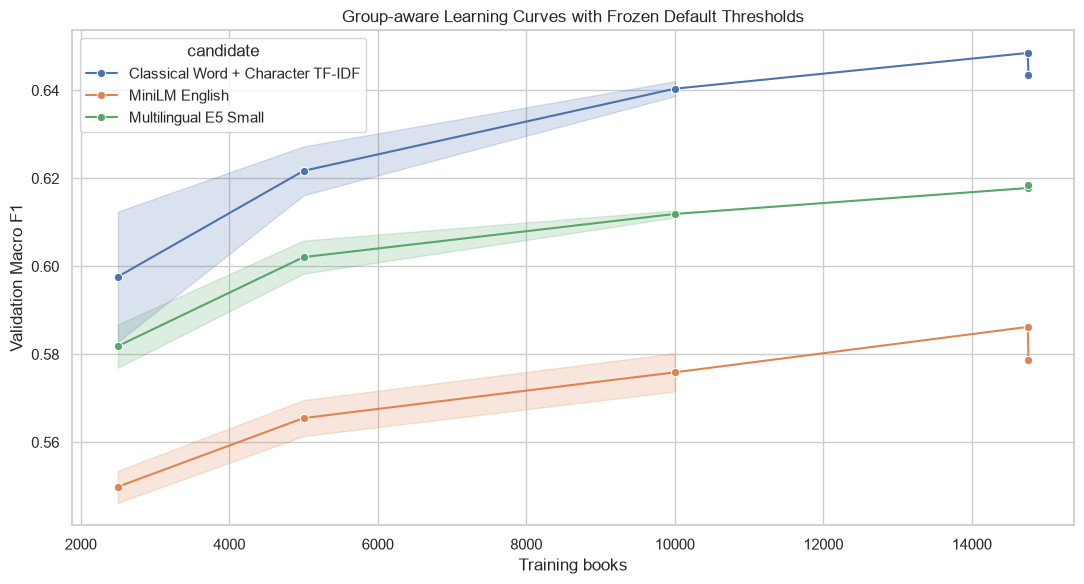

In [18]:
def sample_grouped_training_positions(
    pool_positions: np.ndarray,
    group_values: np.ndarray,
    target_books: int,
    random_state: int,
) -> np.ndarray:
    # Select whole work groups until the requested approximate book count is reached.
    rng = np.random.default_rng(random_state)
    group_frame = pd.DataFrame({"position": pool_positions, "group": group_values[pool_positions]})
    unique_groups = group_frame["group"].drop_duplicates().to_numpy(copy=True)
    rng.shuffle(unique_groups)
    chosen_groups: list[str] = []
    books_selected = 0
    group_sizes = group_frame.groupby("group").size()
    for group in unique_groups:
        chosen_groups.append(group)
        books_selected += int(group_sizes.loc[group])
        if books_selected >= target_books:
            break
    return pool_positions[np.isin(group_values[pool_positions], chosen_groups)]


# Use repeated group-aware validation splits so editions of one work never cross curve partitions.
learning_curve_rows: list[dict[str, object]] = []
curve_splitter = GroupShuffleSplit(
    n_splits=LEARNING_CURVE_REPEATS, test_size=0.20, random_state=RANDOM_STATE + 20
)
development_indices = np.arange(len(y_development))

for repeat, (curve_pool, curve_validation) in enumerate(
    curve_splitter.split(development_indices, y_development, groups=development_groups), start=1
):
    dynamic_targets = [target for target in LEARNING_CURVE_TARGETS if target < len(curve_pool)]
    dynamic_targets.append(len(curve_pool))
    for target_books in sorted(set(dynamic_targets)):
        train_positions = sample_grouped_training_positions(
            curve_pool, development_groups, target_books, RANDOM_STATE + 100 * repeat + target_books
        )
        # Skip undersized samples that cannot train all one-vs-rest genre classifiers.
        if (y_development[train_positions].sum(axis=0) == 0).any():
            continue
        for candidate_name, full_features in candidate_features.items():
            development_features = full_features[development_mask]
            estimator = build_candidate_pipeline(candidate_name)
            # Freeze regularization here so the curve isolates the effect of training-set size.
            estimator.set_params(
                **{"classifier__estimator__C": CANDIDATE_CONFIGS[candidate_name]["frozen_curve_c"]}
            )
            started_at = perf_counter()
            estimator.fit(development_features[train_positions], y_development[train_positions])
            predictions = np.asarray(estimator.predict(development_features[curve_validation])).astype(np.int8)
            learning_curve_rows.append(
                {
                    "repeat": repeat,
                    "candidate": candidate_name,
                    "target_training_books": target_books,
                    "actual_training_books": len(train_positions),
                    "validation_books": len(curve_validation),
                    "macro_f1": f1_score(
                        y_development[curve_validation], predictions, average="macro", zero_division=0
                    ),
                    "fit_seconds": perf_counter() - started_at,
                }
            )

# Aggregate repeats for readable trends while retaining raw runs in the exported report.
learning_curve_results = pd.DataFrame(learning_curve_rows)
learning_curve_summary = (
    learning_curve_results.groupby(["candidate", "target_training_books"], as_index=False)
    .agg(
        actual_training_books=("actual_training_books", "mean"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        fit_seconds_mean=("fit_seconds", "mean"),
    )
)
display(learning_curve_summary.round(4))

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=learning_curve_results,
    x="actual_training_books",
    y="macro_f1",
    hue="candidate",
    marker="o",
    errorbar="sd",
)
plt.title("Group-aware Learning Curves with Frozen Default Thresholds")
plt.xlabel("Training books")
plt.ylabel("Validation Macro F1")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "grouped_learning_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Nested out-of-fold genre and language diagnostics

,candidate,threshold_policy,language_group,books,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,Classical Word + Character TF-IDF,Default,English,7833,0.6708,0.7374,0.7389,0.2205,0.1477,0.7243
1,Classical Word + Character TF-IDF,Default,Non-English,3168,0.5155,0.6213,0.6179,0.1035,0.2157,0.5376
2,Classical Word + Character TF-IDF,Default,Unknown,7461,0.6594,0.7250,0.7274,0.2576,0.1422,0.7079
3,Classical Word + Character TF-IDF,Inner-OOF tuned,English,7833,0.6748,0.7466,0.7479,0.2178,0.1489,0.7243
4,Classical Word + Character TF-IDF,Inner-OOF tuned,Non-English,3168,0.5137,0.6282,0.6220,0.0912,0.2241,0.5376
5,Classical Word + Character TF-IDF,Inner-OOF tuned,Unknown,7461,0.6588,0.7270,0.7303,0.2379,0.1478,0.7079
6,MiniLM English,Default,English,7833,0.5985,0.6759,0.7006,0.1280,0.2044,0.6801
7,MiniLM English,Default,Non-English,3168,0.4750,0.5404,0.5798,0.0338,0.3145,0.4880
8,MiniLM English,Default,Unknown,7461,0.5930,0.6534,0.6829,0.1406,0.2036,0.6660
9,MiniLM English,Inner-OOF tuned,English,7833,0.6402,0.7251,0.7243,0.1791,0.1631,0.6801


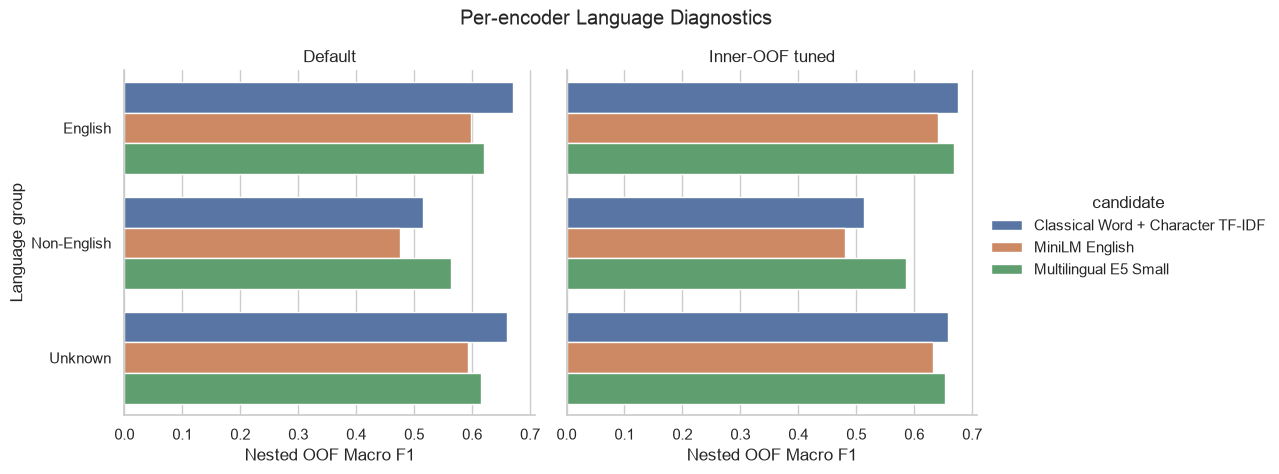

,genre,support,precision,recall,f1,average_precision
0,fiction,12150,0.811,0.826,0.818,0.869
3,non-fiction,4972,0.772,0.825,0.798,0.859
2,romance,6661,0.761,0.772,0.766,0.856
4,"fantasy, paranormal",5372,0.685,0.722,0.703,0.768
1,"history, historical fiction, biography",6294,0.680,0.712,0.696,0.764
5,"mystery, thriller, crime",5105,0.650,0.681,0.665,0.749
7,children,2432,0.561,0.641,0.598,0.658
6,young-adult,3694,0.469,0.600,0.526,0.525
9,poetry,729,0.556,0.457,0.502,0.529
8,"comics, graphic",1531,0.382,0.405,0.393,0.396



### Result interpretation — stability slices

- The strongest representation/policy/language slice is **Classical Word + Character TF-IDF / Inner-OOF tuned / English** at Macro F1 **0.675**.
- The weakest retained slice is **MiniLM English / Default / Non-English** at **0.475** (n=3,168).
- These are outer-fold diagnostics on language metadata, not causal evidence. Encoder routing should be considered only if differences repeat across folds and a fresh holdout.


In [19]:
development_frame = analysis.loc[development_mask].reset_index(drop=True)

# Compare language slices for every representation and threshold policy using honest outer-fold predictions.
language_slice_rows: list[dict[str, object]] = []
for candidate_name, oof_artifacts in nested_oof.items():
    for policy in ["Default", "Inner-OOF tuned"]:
        predictions = oof_artifacts[policy]
        for language_group in ["English", "Non-English", "Unknown"]:
            slice_mask = development_frame["language_group"].eq(language_group).to_numpy()
            # Suppress very small language slices whose aggregate F1 would be too unstable.
            if slice_mask.sum() < 50:
                continue
            metrics = multilabel_metrics(
                y_development[slice_mask], predictions[slice_mask], oof_artifacts["scores"][slice_mask]
            )
            language_slice_rows.append(
                {
                    "candidate": candidate_name,
                    "threshold_policy": policy,
                    "language_group": language_group,
                    "books": int(slice_mask.sum()),
                    **metrics,
                }
            )

language_slice_metrics = pd.DataFrame(language_slice_rows)
display(language_slice_metrics.round(4))

g = sns.catplot(
    data=language_slice_metrics,
    y="language_group",
    x="macro_f1",
    hue="candidate",
    col="threshold_policy",
    kind="bar",
    height=4.5,
    aspect=1.15,
    sharex=True,
)
g.set_axis_labels("Nested OOF Macro F1", "Language group")
g.set_titles("{col_name}")
g.figure.suptitle("Per-encoder Language Diagnostics", y=1.05)
g.figure.savefig(FIGURES_DIR / "nested_language_slices.png", dpi=160, bbox_inches="tight")
plt.show()

# Report label-level stability for the experiment locked for fresh-test evaluation.
selected_oof_predictions = nested_oof[selected_candidate][selected_policy]
selected_oof_scores = nested_oof[selected_candidate]["scores"]
# Decompose the selected nested result to identify rare-label precision/recall tradeoffs.
precision, recall, per_genre_f1, support = precision_recall_fscore_support(
    y_development, selected_oof_predictions, average=None, zero_division=0
)
selected_nested_per_genre = pd.DataFrame(
    {
        "genre": TARGET_GENRES,
        "support": support.astype(int),
        "precision": precision,
        "recall": recall,
        "f1": per_genre_f1,
        "average_precision": average_precision_score(y_development, selected_oof_scores, average=None),
    }
).sort_values("f1", ascending=False)
display(selected_nested_per_genre.round(3))

best_language = language_slice_metrics.sort_values("macro_f1", ascending=False).iloc[0]
worst_language = language_slice_metrics.sort_values("macro_f1", ascending=True).iloc[0]
display(
    Markdown(
        f'''
### Result interpretation — stability slices

- The strongest representation/policy/language slice is **{best_language['candidate']} / {best_language['threshold_policy']} / {best_language['language_group']}** at Macro F1 **{best_language['macro_f1']:.3f}**.
- The weakest retained slice is **{worst_language['candidate']} / {worst_language['threshold_policy']} / {worst_language['language_group']}** at **{worst_language['macro_f1']:.3f}** (n={int(worst_language['books']):,}).
- These are outer-fold diagnostics on language metadata, not causal evidence. Encoder routing should be considered only if differences repeat across folds and a fresh holdout.
'''
    )
)

## 9. Fit the locked winner and access the fresh test once

In [22]:
# Slice only the already-locked representation; alternative candidates never access fresh test labels.
selected_full_features = candidate_features[selected_candidate]
X_development = selected_full_features[development_mask]
X_test = selected_full_features[test_mask]

# Repeat selection internally on all development data, then fit the one predeclared final pipeline.
final_search_started = perf_counter()
final_search = GridSearchCV(
    build_candidate_pipeline(selected_candidate),
    parameter_grid(selected_candidate),
    scoring=SCORING,
    refit="macro_f1",
    cv=GroupKFold(n_splits=FINAL_CV_SPLITS),
    n_jobs=N_JOBS,
    error_score="raise",
)
final_search.fit(X_development, y_development, groups=development_groups)

# Relearn thresholds from development-only OOF scores when calibration earned eligibility.
if selected_policy == "Inner-OOF tuned":
    development_oof_scores = cross_val_predict(
        clone(final_search.best_estimator_),
        X_development,
        y_development,
        groups=development_groups,
        cv=GroupKFold(n_splits=FINAL_CV_SPLITS),
        method="decision_function",
        n_jobs=N_JOBS,
    )
    final_thresholds = tune_per_label_thresholds(y_development, development_oof_scores)
else:
    final_thresholds = np.zeros(len(TARGET_GENRES), dtype=np.float32)

final_pipeline = final_search.best_estimator_
final_training_seconds = perf_counter() - final_search_started

# This is the notebook's only model access to the fresh final test partition.
final_test_scores = continuous_scores(final_pipeline, X_test)
final_test_predictions = predictions_from_thresholds(final_test_scores, final_thresholds)
final_test_metric_values = multilabel_metrics(y_test, final_test_predictions, final_test_scores)

final_test_metrics = pd.DataFrame(
    [
        {
            "candidate": selected_candidate,
            "threshold_policy": selected_policy,
            "best_parameters": json.dumps(final_search.best_params_, sort_keys=True),
            "training_and_calibration_seconds": final_training_seconds,
            **final_test_metric_values,
        }
    ]
)
final_threshold_table = pd.DataFrame({"genre": TARGET_GENRES, "decision_threshold": final_thresholds})
display(final_test_metrics.round(4))
display(final_threshold_table.round(4))

# Report per-genre test behavior after the single aggregate evaluation, without retuning.
test_precision, test_recall, test_f1, test_support = precision_recall_fscore_support(
    y_test, final_test_predictions, average=None, zero_division=0
)
final_test_per_genre = pd.DataFrame(
    {
        "genre": TARGET_GENRES,
        "support": test_support.astype(int),
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "average_precision": average_precision_score(y_test, final_test_scores, average=None),
    }
).sort_values("f1", ascending=False)
display(final_test_per_genre.round(3))

nested_to_test_change = (
    final_test_metric_values["macro_f1"] - selected_nested_row["selection_macro_f1"]
)
display(
    Markdown(
        f'''
### Result interpretation — fresh locked test

- **{selected_candidate} / {selected_policy}** achieves fresh-test Macro F1 **{final_test_metric_values['macro_f1']:.4f}**, a change of **{nested_to_test_change:+.4f}** from its nested selection estimate.
- Micro F1 is **{final_test_metric_values['micro_f1']:.4f}**, macro average precision is **{final_test_metric_values['macro_average_precision']:.4f}**, and Hamming loss is **{final_test_metric_values['hamming_loss']:.4f}**.
- This fresh test result is now frozen. Historical Notebook 04–05 scores came from a different cohort and remain context rather than direct same-sample comparisons.
'''
    )
)

,candidate,threshold_policy,best_parameters,training_and_calibration_seconds,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,Classical Word + Character TF-IDF,Default,"{""classifier__estimator__C"": 0.1}",99.6118,0.6514,0.7152,0.7181,0.2045,0.158,0.7052


,genre,decision_threshold
0,fiction,0.0
1,"history, historical fiction, biography",0.0
2,romance,0.0
3,non-fiction,0.0
4,"fantasy, paranormal",0.0
5,"mystery, thriller, crime",0.0
6,young-adult,0.0
7,children,0.0
8,"comics, graphic",0.0
9,poetry,0.0


,genre,support,precision,recall,f1,average_precision
0,fiction,2129,0.810,0.829,0.819,0.870
3,non-fiction,904,0.800,0.840,0.819,0.871
2,romance,1178,0.751,0.782,0.766,0.858
1,"history, historical fiction, biography",1161,0.688,0.717,0.702,0.781
4,"fantasy, paranormal",915,0.673,0.732,0.702,0.756
5,"mystery, thriller, crime",912,0.643,0.688,0.665,0.747
7,children,399,0.552,0.689,0.613,0.689
6,young-adult,628,0.465,0.621,0.532,0.562
9,poetry,134,0.578,0.440,0.500,0.501
8,"comics, graphic",287,0.366,0.432,0.396,0.416



### Result interpretation — fresh locked test

- **Classical Word + Character TF-IDF / Default** achieves fresh-test Macro F1 **0.6514**, a change of **+0.0049** from its nested selection estimate.
- Micro F1 is **0.7152**, macro average precision is **0.7052**, and Hamming loss is **0.1580**.
- This fresh test result is now frozen. Historical Notebook 04–05 scores came from a different cohort and remain context rather than direct same-sample comparisons.


## 10. Export reproducible Notebook 06 classification artifacts

In [25]:
# Serialize the one locked fresh-test classifier and export compact classification evidence.
selected_model_path = MODELS_DIR / "selected_fresh_classifier_v2.joblib"
joblib.dump(final_pipeline, selected_model_path)
selected_model_size_mb = selected_model_path.stat().st_size / (1024**2)

# Export detailed and summarized evidence separately to keep notebook displays concise.
nested_fold_results.to_csv(REPORTS_DIR / "notebook06_nested_fold_results.csv", index=False)
nested_summary.to_csv(REPORTS_DIR / "notebook06_nested_summary.csv", index=False)
candidate_selection.to_csv(REPORTS_DIR / "notebook06_candidate_selection.csv", index=False)
learning_curve_results.to_csv(REPORTS_DIR / "notebook06_learning_curve_results.csv", index=False)
learning_curve_summary.to_csv(REPORTS_DIR / "notebook06_learning_curve_summary.csv", index=False)
language_slice_metrics.to_csv(REPORTS_DIR / "notebook06_language_slices.csv", index=False)
selected_nested_per_genre.to_csv(REPORTS_DIR / "notebook06_nested_per_genre.csv", index=False)
final_test_metrics.to_csv(REPORTS_DIR / "notebook06_final_test_metrics.csv", index=False)
final_test_per_genre.to_csv(REPORTS_DIR / "notebook06_final_test_per_genre.csv", index=False)
final_threshold_table.to_csv(REPORTS_DIR / "notebook06_final_thresholds.csv", index=False)
embedding_inventory.to_csv(REPORTS_DIR / "notebook06_embedding_inventory.csv", index=False)

# Export selected nested OOF errors for reproducible slice and calibration follow-up.
def active_label_names(row: np.ndarray) -> str:
    return " | ".join(genre for genre, active in zip(TARGET_GENRES, row) if active)


selected_oof_export = development_frame[
    ["book_id", "work_id", "title", "language_group", "text_word_count"]
].copy()
selected_oof_export["true_genres"] = [active_label_names(row) for row in y_development]
selected_oof_export["predicted_genres"] = [active_label_names(row) for row in selected_oof_predictions]
selected_oof_export["label_error_count"] = np.abs(y_development - selected_oof_predictions).sum(axis=1)
selected_oof_export.to_csv(REPORTS_DIR / "notebook06_selected_nested_oof_errors.csv", index=False)

# Keep fresh-test errors separate from nested OOF errors because they have different evidential roles.
test_error_export = analysis.loc[
    test_mask,
    ["book_id", "work_id", "title", "language_group", "text_word_count"],
].reset_index(drop=True)
test_error_export["true_genres"] = [active_label_names(row) for row in y_test]
test_error_export["predicted_genres"] = [active_label_names(row) for row in final_test_predictions]
test_error_export["label_error_count"] = np.abs(y_test - final_test_predictions).sum(axis=1)
test_error_export.to_csv(REPORTS_DIR / "notebook06_fresh_test_errors.csv", index=False)

# Capture the frozen Phase 1 protocol and selected result in a machine-readable continuity artifact.
experiment_manifest = {
    "notebook": "06_scaled_genre_classification_stability_and_calibration",
    "research_phase": "Phase 1 - genre classification",
    "random_state": RANDOM_STATE,
    "scaled_sample_size": SCALED_SAMPLE_SIZE,
    "eligible_labeled_books": len(analysis),
    "cohort_fingerprint": COHORT_FINGERPRINT,
    "outer_cv_splits": OUTER_CV_SPLITS,
    "inner_cv_splits": INNER_CV_SPLITS,
    "primary_metric": "macro_f1",
    "material_transformer_gain": MATERIAL_MACRO_F1_GAIN,
    "minimum_calibration_gain": MIN_CALIBRATION_GAIN,
    "selected_candidate": selected_candidate,
    "selected_policy": selected_policy,
    "nested_selection_macro_f1": float(selected_nested_row["selection_macro_f1"]),
    "fresh_test_macro_f1": float(final_test_metric_values["macro_f1"]),
    "selected_parameters": final_search.best_params_,
    "selected_model_size_mb": selected_model_size_mb,
    "prior_books_and_works_excluded": True,
    "fresh_test_accessed_for_one_locked_pipeline": True,
    "fresh_test_status": "closed",
    "semantic_neighbor_evaluation": "deferred to Phase 2",
}
manifest_path = MODELS_DIR / "notebook06_experiment_manifest_v2.json"
with manifest_path.open("w", encoding="utf-8") as handle:
    json.dump(experiment_manifest, handle, indent=2)

exported_artifacts = pd.DataFrame(
    {
        "artifact_family": [
            "Fresh books",
            "Fresh genres",
            "Fresh split",
            "Scaled embeddings",
            "Embedding manifests",
            "Nested results",
            "Learning curves",
            "Language slices",
            "Fresh test metrics",
            "Selected classifier",
            "Experiment manifest",
            "Figures",
        ],
        "location": [
            str(FILES["scaled_books"]),
            str(FILES["scaled_genres"]),
            str(FILES["fresh_split"]),
            str(PROCESSED_DIR / "book_transformer_embeddings_*_v2.parquet"),
            str(MODELS_DIR / "*_embedding_manifest_v2.json"),
            str(REPORTS_DIR / "notebook06_nested_*.csv"),
            str(REPORTS_DIR / "notebook06_learning_curve_*.csv"),
            str(REPORTS_DIR / "notebook06_language_slices.csv"),
            str(REPORTS_DIR / "notebook06_final_test_metrics.csv"),
            str(selected_model_path),
            str(manifest_path),
            str(FIGURES_DIR),
        ],
    }
)
display(exported_artifacts)

,artifact_family,location
0,Fresh books,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/books_s...
1,Fresh genres,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_ge...
2,Fresh split,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/resea...
3,Scaled embeddings,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_...
4,Embedding manifests,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook06/*_...
5,Nested results,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook06_n...
6,Learning curves,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook06_l...
7,Language slices,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook06_l...
8,Fresh test metrics,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook06_f...
9,Selected classifier,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook06/se...


## 11. Measured Phase 1 classification checkpoint

### Research answer

On a completely fresh scaled cohort, the classical **Word + Character TF-IDF / Linear SVM** remains the Phase 1 genre-classification baseline. Tuned Multilingual E5 produced the highest raw nested Macro F1 at **0.6543**, but its **+0.0078** gain over the comparable classical result of **0.6465** did not clear the predeclared **+0.01** material-improvement threshold. The resulting classical lock achieved **0.6514 Macro F1** on the one-time fresh test, only **+0.0049** from its nested estimate, supporting the stability of the selection decision.

### Key measured findings

- **Fresh scaled evidence:** the deterministic 25,000-description sample produced **21,699 labeled books** across **20,921 work groups**. The split contains **18,462 development books** and **3,237 test books**, with zero work-group overlap and no overlap with the original 5,000-book sample.
- **Stable classical model:** the classical default policy scored **0.6465 ± 0.0026 Macro F1** across four outer folds. All four inner searches selected `C=0.1`, indicating low hyperparameter instability.
- **Calibration helped transformers, but did not justify replacement:** inner-OOF thresholds improved E5 by **+0.0410** and MiniLM by **+0.0386** Macro F1. Classical calibration added only **+0.0020**, below the +0.005 eligibility rule, so its default zero thresholds were retained.
- **Fresh test quality:** the locked classical pipeline achieved **0.6514 Macro F1**, **0.7152 Micro F1**, **0.7052 macro average precision**, **0.2045 subset accuracy**, and **0.1580 Hamming loss**.
- **Learning with scale:** from approximately 2,500 to 14,750 training books, default-threshold Macro F1 increased by about **+0.0484** for classical TF-IDF, **+0.0362** for E5, and **+0.0326** for MiniLM. More labeled data continued to help all representations, but the classical model retained the strongest default-threshold curve.
- **Language complementarity:** tuned E5 exceeded default classical TF-IDF by **+0.0702 Macro F1** on the Non-English metadata slice, while remaining approximately level on English (**−0.0015**) and slightly lower on Unknown-language records (**−0.0062**). This supports a future development-only fusion or routing hypothesis, not a post-test model change.
- **Genre behavior:** final-test F1 was strongest for fiction (**0.819**), non-fiction (**0.819**), and romance (**0.766**). Comics/graphic (**0.396**), poetry (**0.500**), and young-adult (**0.532**) remain the clearest improvement targets.
- **Per-genre stability:** every final-test genre F1 remained within approximately **0.022** of its nested OOF estimate. The largest positive differences were non-fiction (+0.021) and children (+0.015); no genre declined by more than 0.002.
- **Operational evidence:** the selected classifier is approximately **7.52 MB** and required **99.6 seconds** for final grouped search and fitting. The two reusable 384-dimensional embedding caches are approximately 47.1 MB each.

### Frozen Phase 1 decisions

1. Preserve **Word + Character TF-IDF / Linear SVM with `C=0.1` and default thresholds** as the scaled classification baseline.
2. Keep Multilingual E5 as a complementary classification candidate, particularly for Non-English descriptions, but do not promote it from this test result.
3. Treat `research_split_v2.parquet` and its fresh test as permanently closed to model selection.
4. Interpret Notebook 04 and Notebook 05 test values as historical context rather than direct same-cohort comparisons.
5. Defer semantic-neighbor evaluation, human relevance ratings, search, and book discovery to Phase 2.

### Limitations

- The ten targets are weak Goodreads genre-family signals rather than curated ground truth.
- Language groups come from incomplete metadata codes rather than verified language detection.
- Only books with sufficiently long descriptions and at least one retained target genre enter the labeled cohort.
- Macro F1 gives every genre equal importance but does not measure hierarchical genre relationships, probability calibration, or product-level usefulness.
- Larger samples reduce variance but do not correct label ambiguity or missing-label bias.

### Phase 1 continuation

The next bounded notebook should compare the frozen classical baseline with **classical/E5 decision-score fusion** and **one task-fine-tuned multilingual encoder** using nested grouped evaluation. Binary cross-entropy versus asymmetric loss may be included as a controlled loss ablation; an ensemble classifier chain is optional only if computationally justified. Exactly one selected pipeline should then be evaluated on a newly sampled untouched holdout to close Phase 1.
